"""
plot_temperature_from_table.py
================================
Temperature sweep plots using exact table data from SCAPS results.
No file parsing needed — data hardcoded directly from the table.

Produces 2 figures:
  1. temperature_params.png  — 4-panel: Jsc, Voc, FF, PCE vs Temperature
  2. temperature_JV.png      — Overlaid J-V curves (reconstructed via diode equation)

HOW TO RUN:
    python plot_temperature_from_table.py
"""

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────────────────────────────────────
# DATA — directly from your SCAPS results table
# ─────────────────────────────────────────────────────────────────────────────

T_arr   = np.array([300,    320,    340,    360,    380,    400   ], dtype=float)
jsc_arr = np.array([34.5085, 34.4878, 34.4635, 34.4345, 34.404, 34.3684])
voc_arr = np.array([0.9286,  0.8966,  0.8642,  0.8314,  0.7982, 0.7646 ])
ff_arr  = np.array([72.5696, 72.3088, 71.9304, 71.4392, 70.8351, 70.1202])
pce_arr = np.array([23.2554, 22.3599, 21.4233, 20.4513, 19.451, 18.4255])

In [3]:
#─────────────────────────────────────────────────────────────────────────────
# COLORS — one distinct color per temperature
# ─────────────────────────────────────────────────────────────────────────────

COLORS = {
    300: "#1A237E",   # deep navy
    320: "#1565C0",   # blue
    340: "#2E7D32",   # green
    360: "#F9A825",   # amber
    380: "#E65100",   # deep orange
    400: "#B71C1C",   # deep red
}
color_list = [COLORS[int(T)] for T in T_arr]

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# DIODE EQUATION — reconstruct J-V curves from Jsc, Voc, T
# ─────────────────────────────────────────────────────────────────────────────

q          = 1.602e-19
k          = 1.381e-23
N_IDEALITY = 1.5

def reconstruct_jv(T_K, jsc, voc, n=N_IDEALITY):
    Vt = (n * k * T_K) / q
    J0 = jsc / (np.exp(voc / Vt) - 1)
    v  = np.linspace(0, voc, 600)
    j  = jsc - J0 * (np.exp(v / Vt) - 1)
    return v, np.maximum(j, 0)

Saved --> temperature_params.png


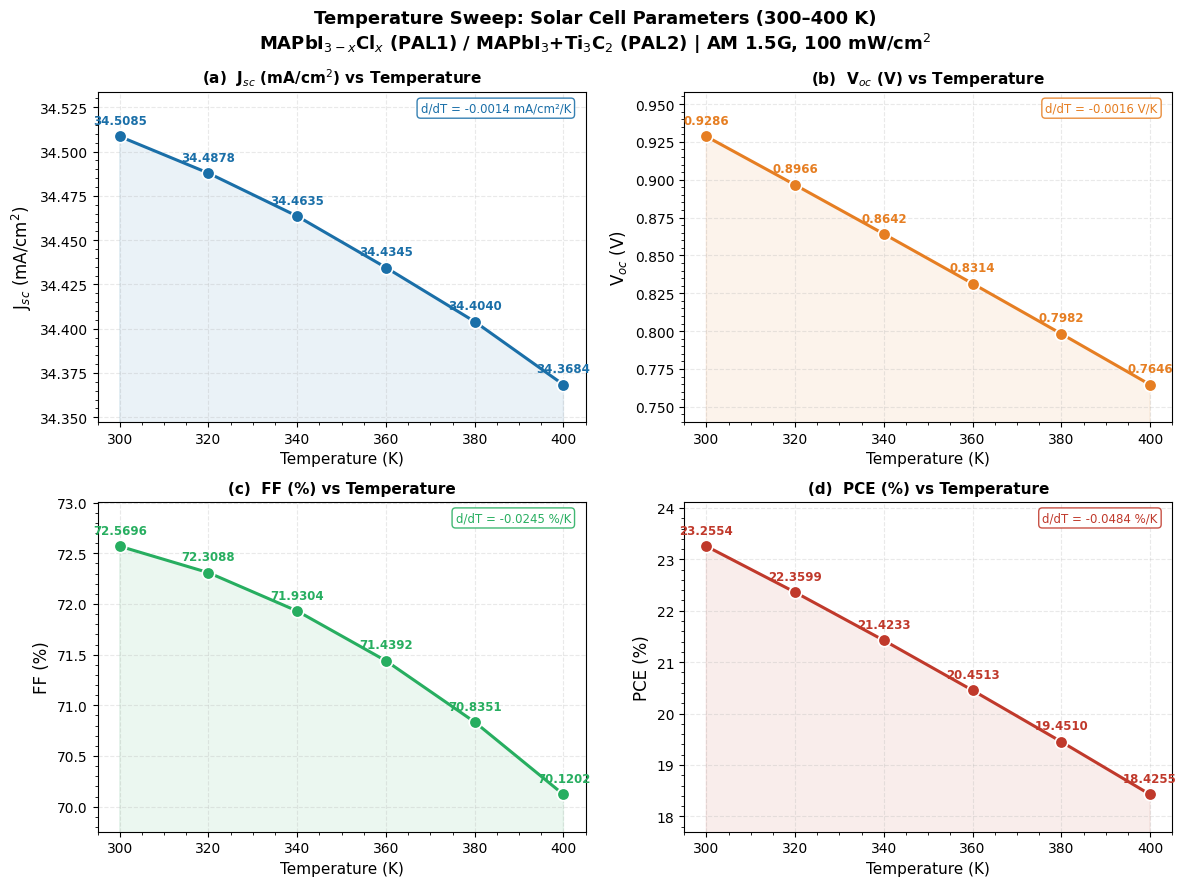

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — 4-Panel Parameter Plots
# ─────────────────────────────────────────────────────────────────────────────

fig1, axes = plt.subplots(2, 2, figsize=(12, 9))
fig1.suptitle(
    "Temperature Sweep: Solar Cell Parameters (300–400 K)\n"
    "MAPbI$_{3-x}$Cl$_x$ (PAL1) / MAPbI$_3$+Ti$_3$C$_2$ (PAL2) "
    "| AM 1.5G, 100 mW/cm$^2$",
    fontsize=13, fontweight="bold"
)

datasets = [
    (jsc_arr, "J$_{sc}$ (mA/cm$^2$)", "#1A6FA8", "(a)"),
    (voc_arr, "V$_{oc}$ (V)",          "#E67E22", "(b)"),
    (ff_arr,  "FF (%)",                "#27AE60", "(c)"),
    (pce_arr, "PCE (%)",               "#C0392B", "(d)"),
]

for ax, (data, ylabel, col, tag) in zip(axes.flat, datasets):

    # main line with markers
    ax.plot(T_arr, data, "o-", color=col,
            linewidth=2.2, markersize=9, zorder=4,
            markerfacecolor=col, markeredgecolor="white",
            markeredgewidth=1.2)
    ax.fill_between(T_arr, data, alpha=0.09, color=col, zorder=1)

    # annotate exact value next to each point
    y_range = data.max() - data.min()
    for xi, yi in zip(T_arr, data):
        ax.annotate(
            f"{yi:.4f}",
            xy=(xi, yi),
            xytext=(xi, yi + y_range * 0.05),
            fontsize=8.5, ha="center", color=col,
            fontweight="bold"
        )

    # temperature coefficient (linear fit)
    slope = np.polyfit(T_arr, data, 1)[0]
    unit_map = {
        "J$_{sc}$ (mA/cm$^2$)": "mA/cm²/K",
        "V$_{oc}$ (V)":         "V/K",
        "FF (%)":               "%/K",
        "PCE (%)":              "%/K",
    }
    ax.text(0.97, 0.97,
            f"d/dT = {slope:.4f} {unit_map[ylabel]}",
            transform=ax.transAxes, fontsize=8.5,
            ha="right", va="top", color=col,
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", edgecolor=col, alpha=0.88))

    ax.set_xlabel("Temperature (K)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"{tag}  {ylabel} vs Temperature",
                 fontsize=11, fontweight="bold")
    ax.set_xlim(295, 405)
    ax.set_ylim(data.min() - y_range * 0.15,
                data.max() + y_range * 0.18)
    ax.set_xticks(T_arr)
    ax.grid(True, alpha=0.28, linestyle="--")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("temperature_params.png", dpi=300, bbox_inches="tight")
print("Saved --> temperature_params.png")
plt.show()

Saved --> temperature_JV.png


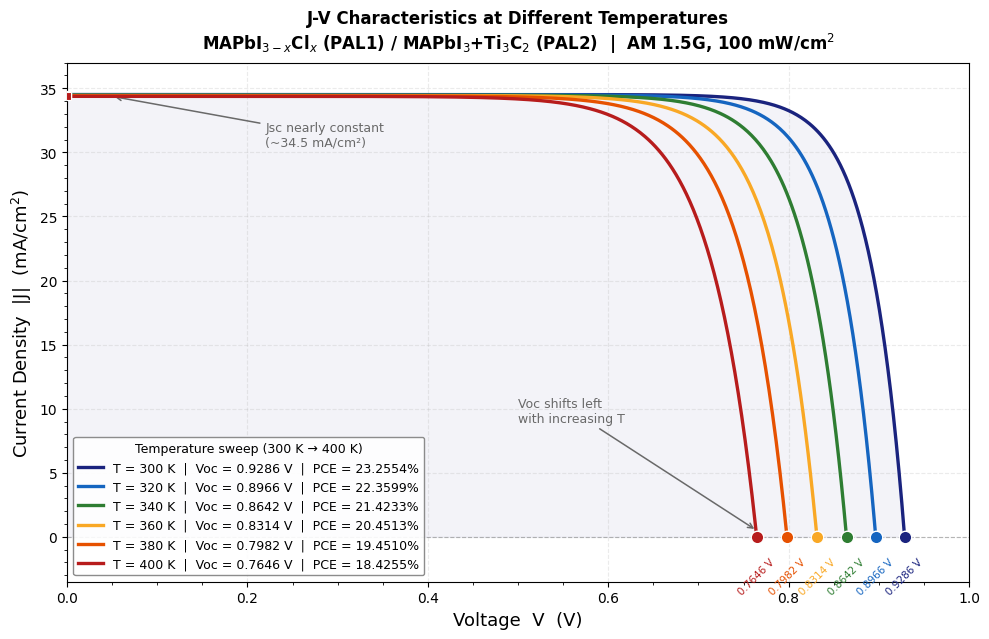

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Overlaid J-V Curves
# ─────────────────────────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(10, 6.5))

for T, jsc, voc, pce, col in zip(
    T_arr, jsc_arr, voc_arr, pce_arr, color_list
):
    v, j = reconstruct_jv(T, jsc, voc)

    ax2.plot(v, j, color=col, linewidth=2.4, zorder=4,
             label=f"T = {int(T)} K  |  "
                   f"Voc = {voc:.4f} V  |  "
                   f"PCE = {pce:.4f}%")

    # Voc marker
    ax2.plot(voc, 0, "o", color=col, markersize=9,
             zorder=6, markeredgecolor="white", markeredgewidth=1)

    # Jsc marker
    ax2.plot(0, jsc, "s", color=col, markersize=6,
             zorder=6, markeredgecolor="white", markeredgewidth=0.8)

    # Voc value label below x-axis
    ax2.text(voc, -1.5,
             f"{voc:.4f} V",
             fontsize=7.5, color=col, ha="center", va="top",
             rotation=45)

# fill under 300K (best) curve
v0, j0 = reconstruct_jv(300, jsc_arr[0], voc_arr[0])
ax2.fill_between(v0, j0, alpha=0.05, color=COLORS[300], zorder=1)

# annotations
ax2.annotate(
    "Jsc nearly constant\n(~34.5 mA/cm²)",
    xy=(0.05, jsc_arr[-1]),
    xytext=(0.22, 30.5),
    fontsize=9, color="dimgray",
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.1)
)
ax2.annotate(
    "Voc shifts left\nwith increasing T",
    xy=(voc_arr[-1], 0.5),
    xytext=(0.50, 9),
    fontsize=9, color="dimgray",
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.1)
)

ax2.set_xlabel("Voltage  V  (V)", fontsize=13)
ax2.set_ylabel("Current Density  |J|  (mA/cm$^2$)", fontsize=13)
ax2.set_title(
    "J-V Characteristics at Different Temperatures\n"
    "MAPbI$_{3-x}$Cl$_x$ (PAL1) / MAPbI$_3$+Ti$_3$C$_2$ (PAL2)"
    "  |  AM 1.5G, 100 mW/cm$^2$",
    fontsize=12, fontweight="bold", pad=10
)
ax2.set_xlim(left=0, right=1.00)
ax2.set_ylim(bottom=-3.5, top=37.0)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax2.legend(
    fontsize=9, loc="lower left",
    framealpha=0.90, edgecolor="gray",
    title="Temperature sweep (300 K → 400 K)",
    title_fontsize=9
)
ax2.grid(True, alpha=0.25, linestyle="--")
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("temperature_JV.png", dpi=300, bbox_inches="tight")
print("Saved --> temperature_JV.png")
plt.show()

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Summary ─────────────────────────────────────────────")
print(f"  dVoc/dT  = {np.polyfit(T_arr, voc_arr, 1)[0]*1000:.3f} mV/K")
print(f"  dPCE/dT  = {np.polyfit(T_arr, pce_arr, 1)[0]:.4f} %/K")
print(f"  dFF/dT   = {np.polyfit(T_arr, ff_arr,  1)[0]:.4f} %/K")
print(f"  dJsc/dT  = {np.polyfit(T_arr, jsc_arr, 1)[0]:.5f} mA/cm²/K")
print("────────────────────────────────────────────────────────")
print("Files: temperature_params.png  |  temperature_JV.png")


── Summary ─────────────────────────────────────────────
  dVoc/dT  = -1.640 mV/K
  dPCE/dT  = -0.0484 %/K
  dFF/dT   = -0.0245 %/K
  dJsc/dT  = -0.00140 mA/cm²/K
────────────────────────────────────────────────────────
Files: temperature_params.png  |  temperature_JV.png
